In [108]:
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import math
import numpy as np

<h2 align="center" style="color:blue;"> 1. Data Loading</h2>

In [109]:
df_customer = pd.read_csv("../data/customers.csv")
df_bureau = pd.read_csv("../data/bureau_data.csv")
df_loan = pd.read_csv("../data/loans.csv")

In [110]:
df = pd.merge(df_customer, df_bureau, how='inner')
df = pd.merge(df, df_loan, how='inner')

In [111]:
print(df.shape)
print(df.info())

(50000, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      50000 non-null  object 
 1   age                          50000 non-null  int64  
 2   gender                       50000 non-null  object 
 3   marital_status               50000 non-null  object 
 4   employment_status            50000 non-null  object 
 5   income                       50000 non-null  int64  
 6   number_of_dependants         50000 non-null  int64  
 7   residence_type               49938 non-null  object 
 8   years_at_current_address     50000 non-null  int64  
 9   city                         50000 non-null  object 
 10  state                        50000 non-null  object 
 11  zipcode                      50000 non-null  int64  
 12  number_of_open_accounts      50000 non-null  int64  
 13  numb

In [112]:
df.default = df.default.astype(int)
df.default.value_counts()

default
0    45703
1     4297
Name: count, dtype: int64

In [113]:
45703/50000

0.91406

clearly, class imbalance is there as 91% row belongs to 0(not defalut) class.

<h2 align="center" style="color:blue;">2. Train Test Split</h2>

In [114]:
X = df.drop(columns=['default'], axis=1)
y = df['default']
X_train ,X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size = 0.25 ,random_state = 5)
df_train = pd.concat([X_train, y_train], axis="columns")
df_test = pd.concat([X_test, y_test], axis="columns")

<h2 align="center" style="color:blue;"> 3. Data Cleaning/Preprocessing</h2>

In [115]:
df_train.isnull().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 46
years_at_current_address        0
city                            0
state                           0
zipcode                         0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd                       0
enquiry_count                   0
credit_utilization_ratio        0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_a

In [116]:
df_train.residence_type.unique()

array(['Mortgage', 'Owned', 'Rented', nan], dtype=object)

In [117]:
mode_residance = X_train.residence_type.mode()[0]

In [118]:
df_train['residence_type'] = df_train.residence_type.fillna(mode_residance)
df_train.residence_type.unique()

array(['Mortgage', 'Owned', 'Rented'], dtype=object)

In [119]:
df_test['residence_type'] = df_test.residence_type.fillna(mode_residance)

In [120]:
df_train.duplicated().sum()

0

In [121]:
df_test.duplicated().sum()

0

In [122]:
columns_continuous=df_train.select_dtypes(include=['int64','float64']).columns.tolist()
columns_categorical=df_train.select_dtypes(include=['object']).columns.tolist()

<h3 style="color:green;">3.1 Numerical Column Cleaning</h3>

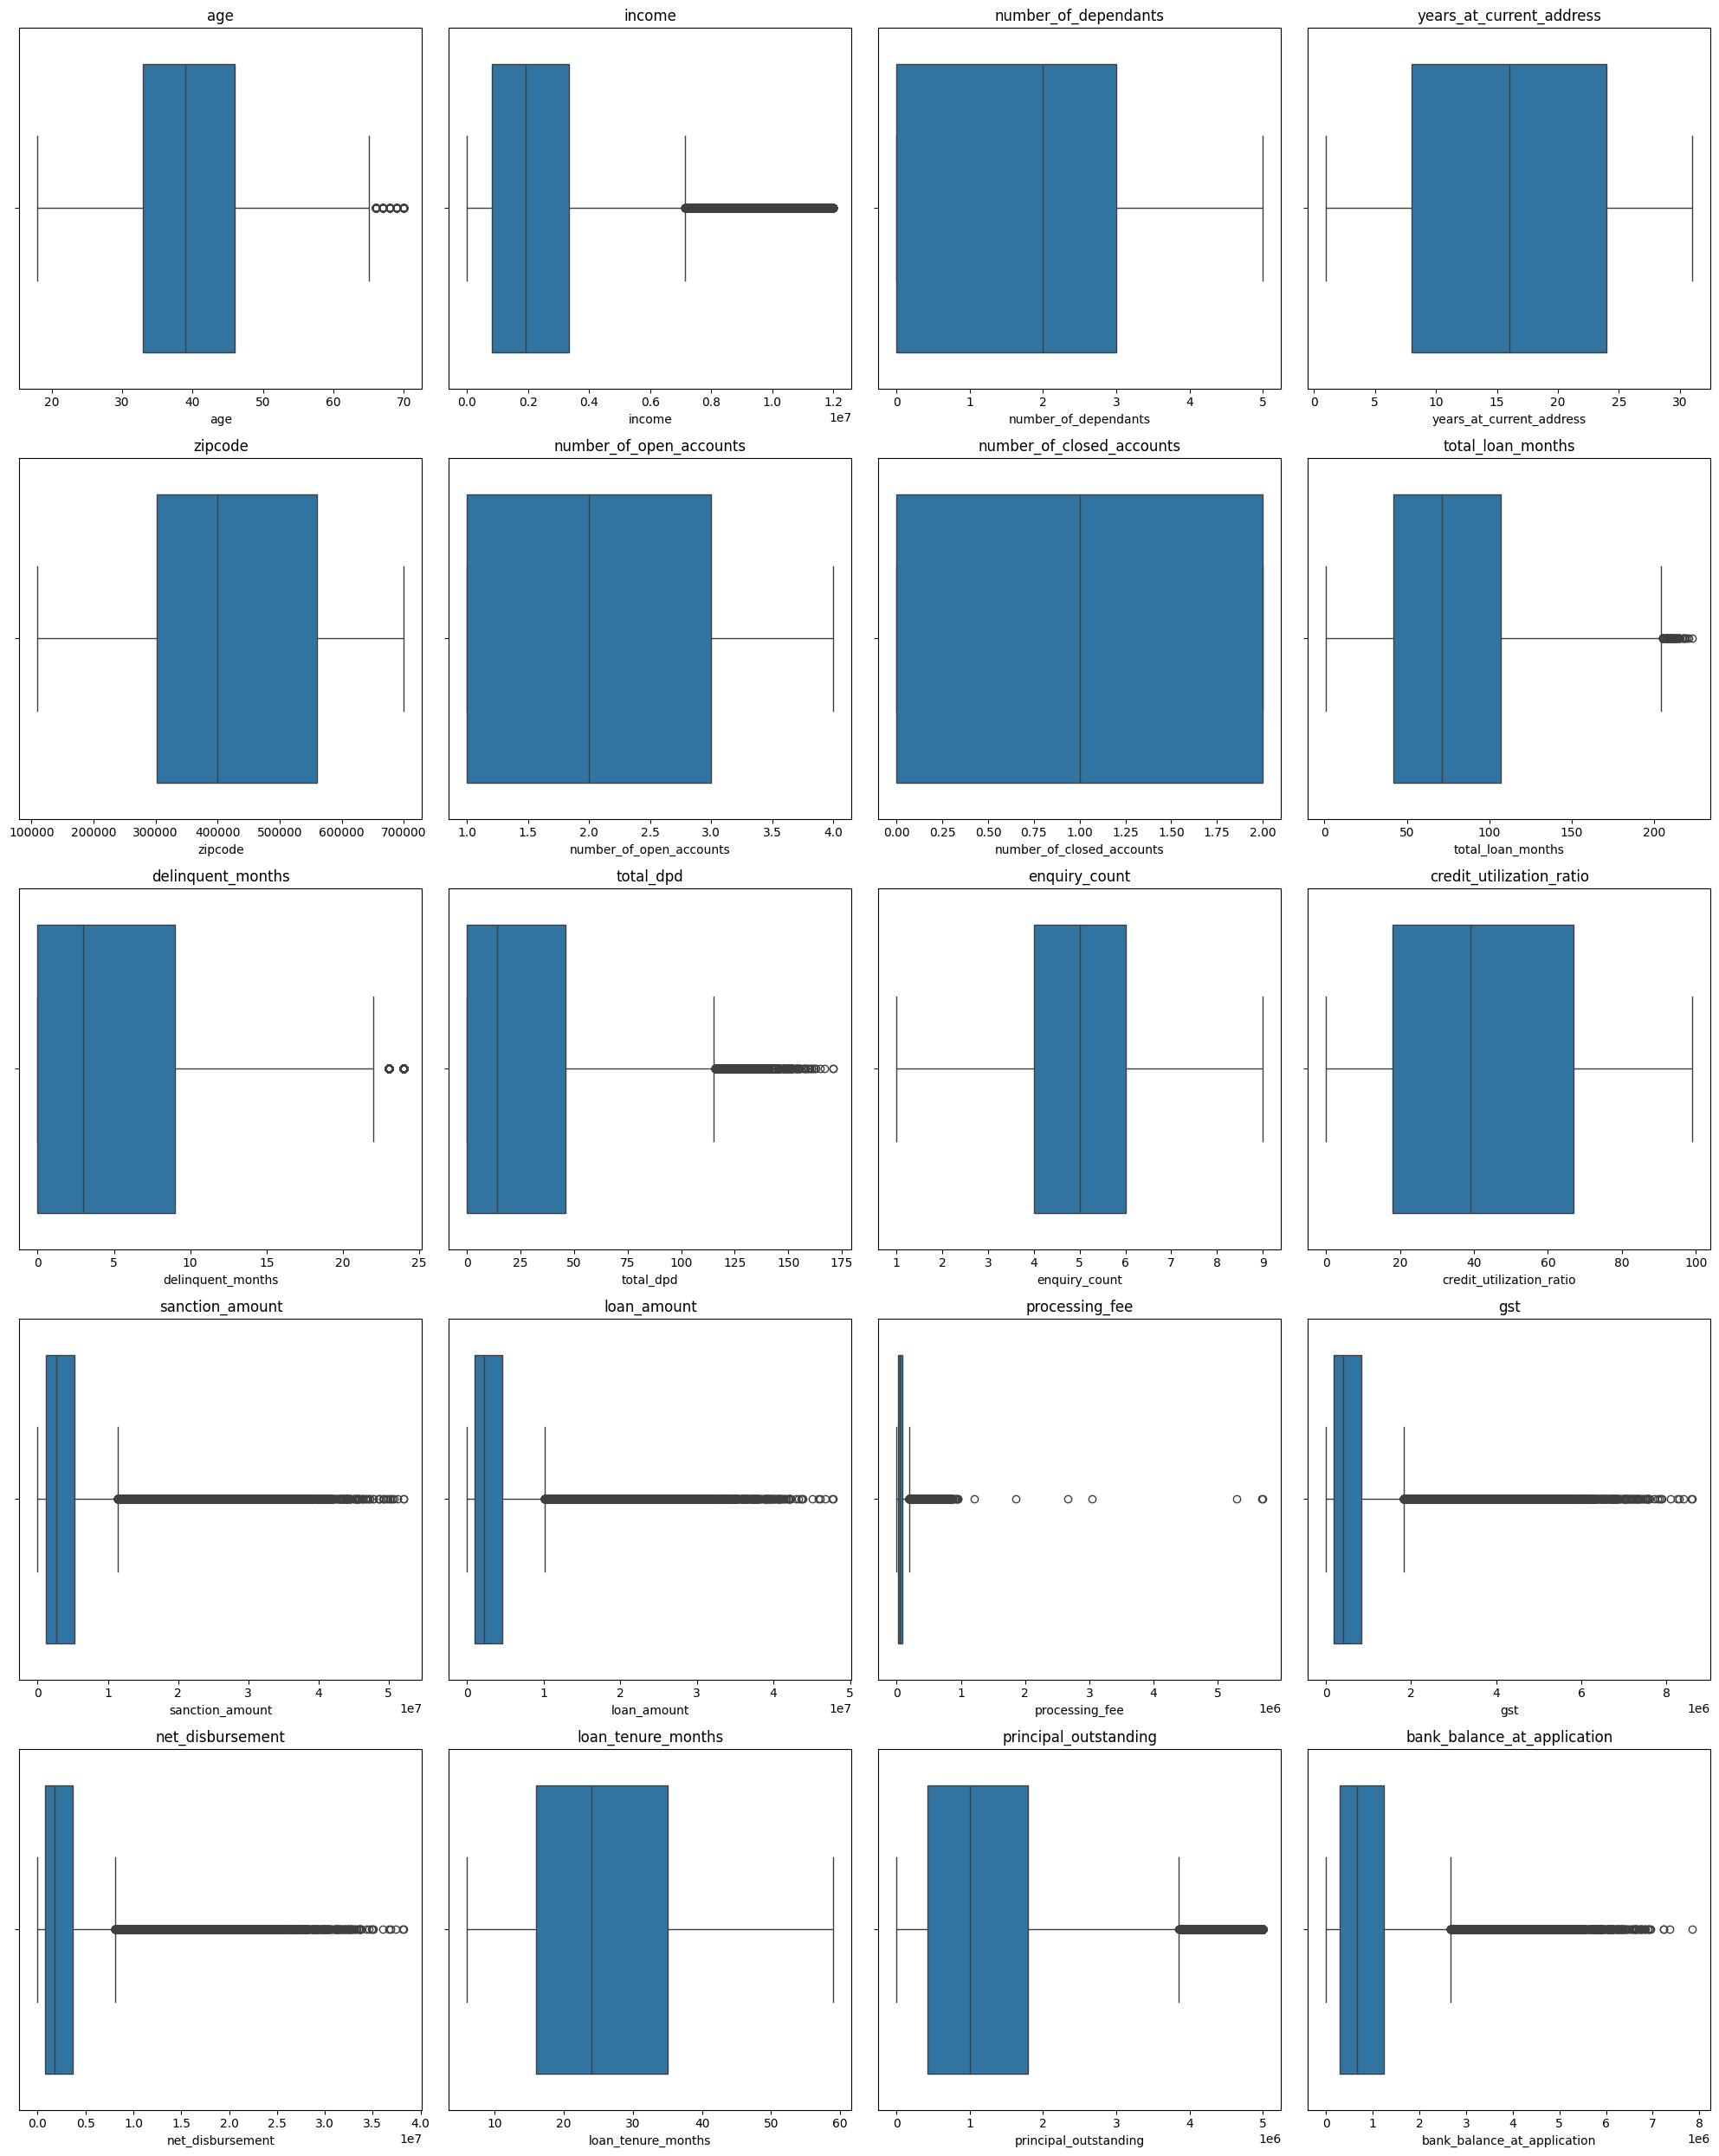

In [123]:
n_cols = 4
n_rows = math.ceil(len(columns_continuous)/n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()
for ax, col in zip(axes, columns_continuous):
    sns.boxplot(x=df_train[col], ax=ax)
    ax.set_title(col)

# # Hide unused subplots
for ax in axes[len(columns_continuous):]:
    ax.set_visible(False)

plt.tight_layout()

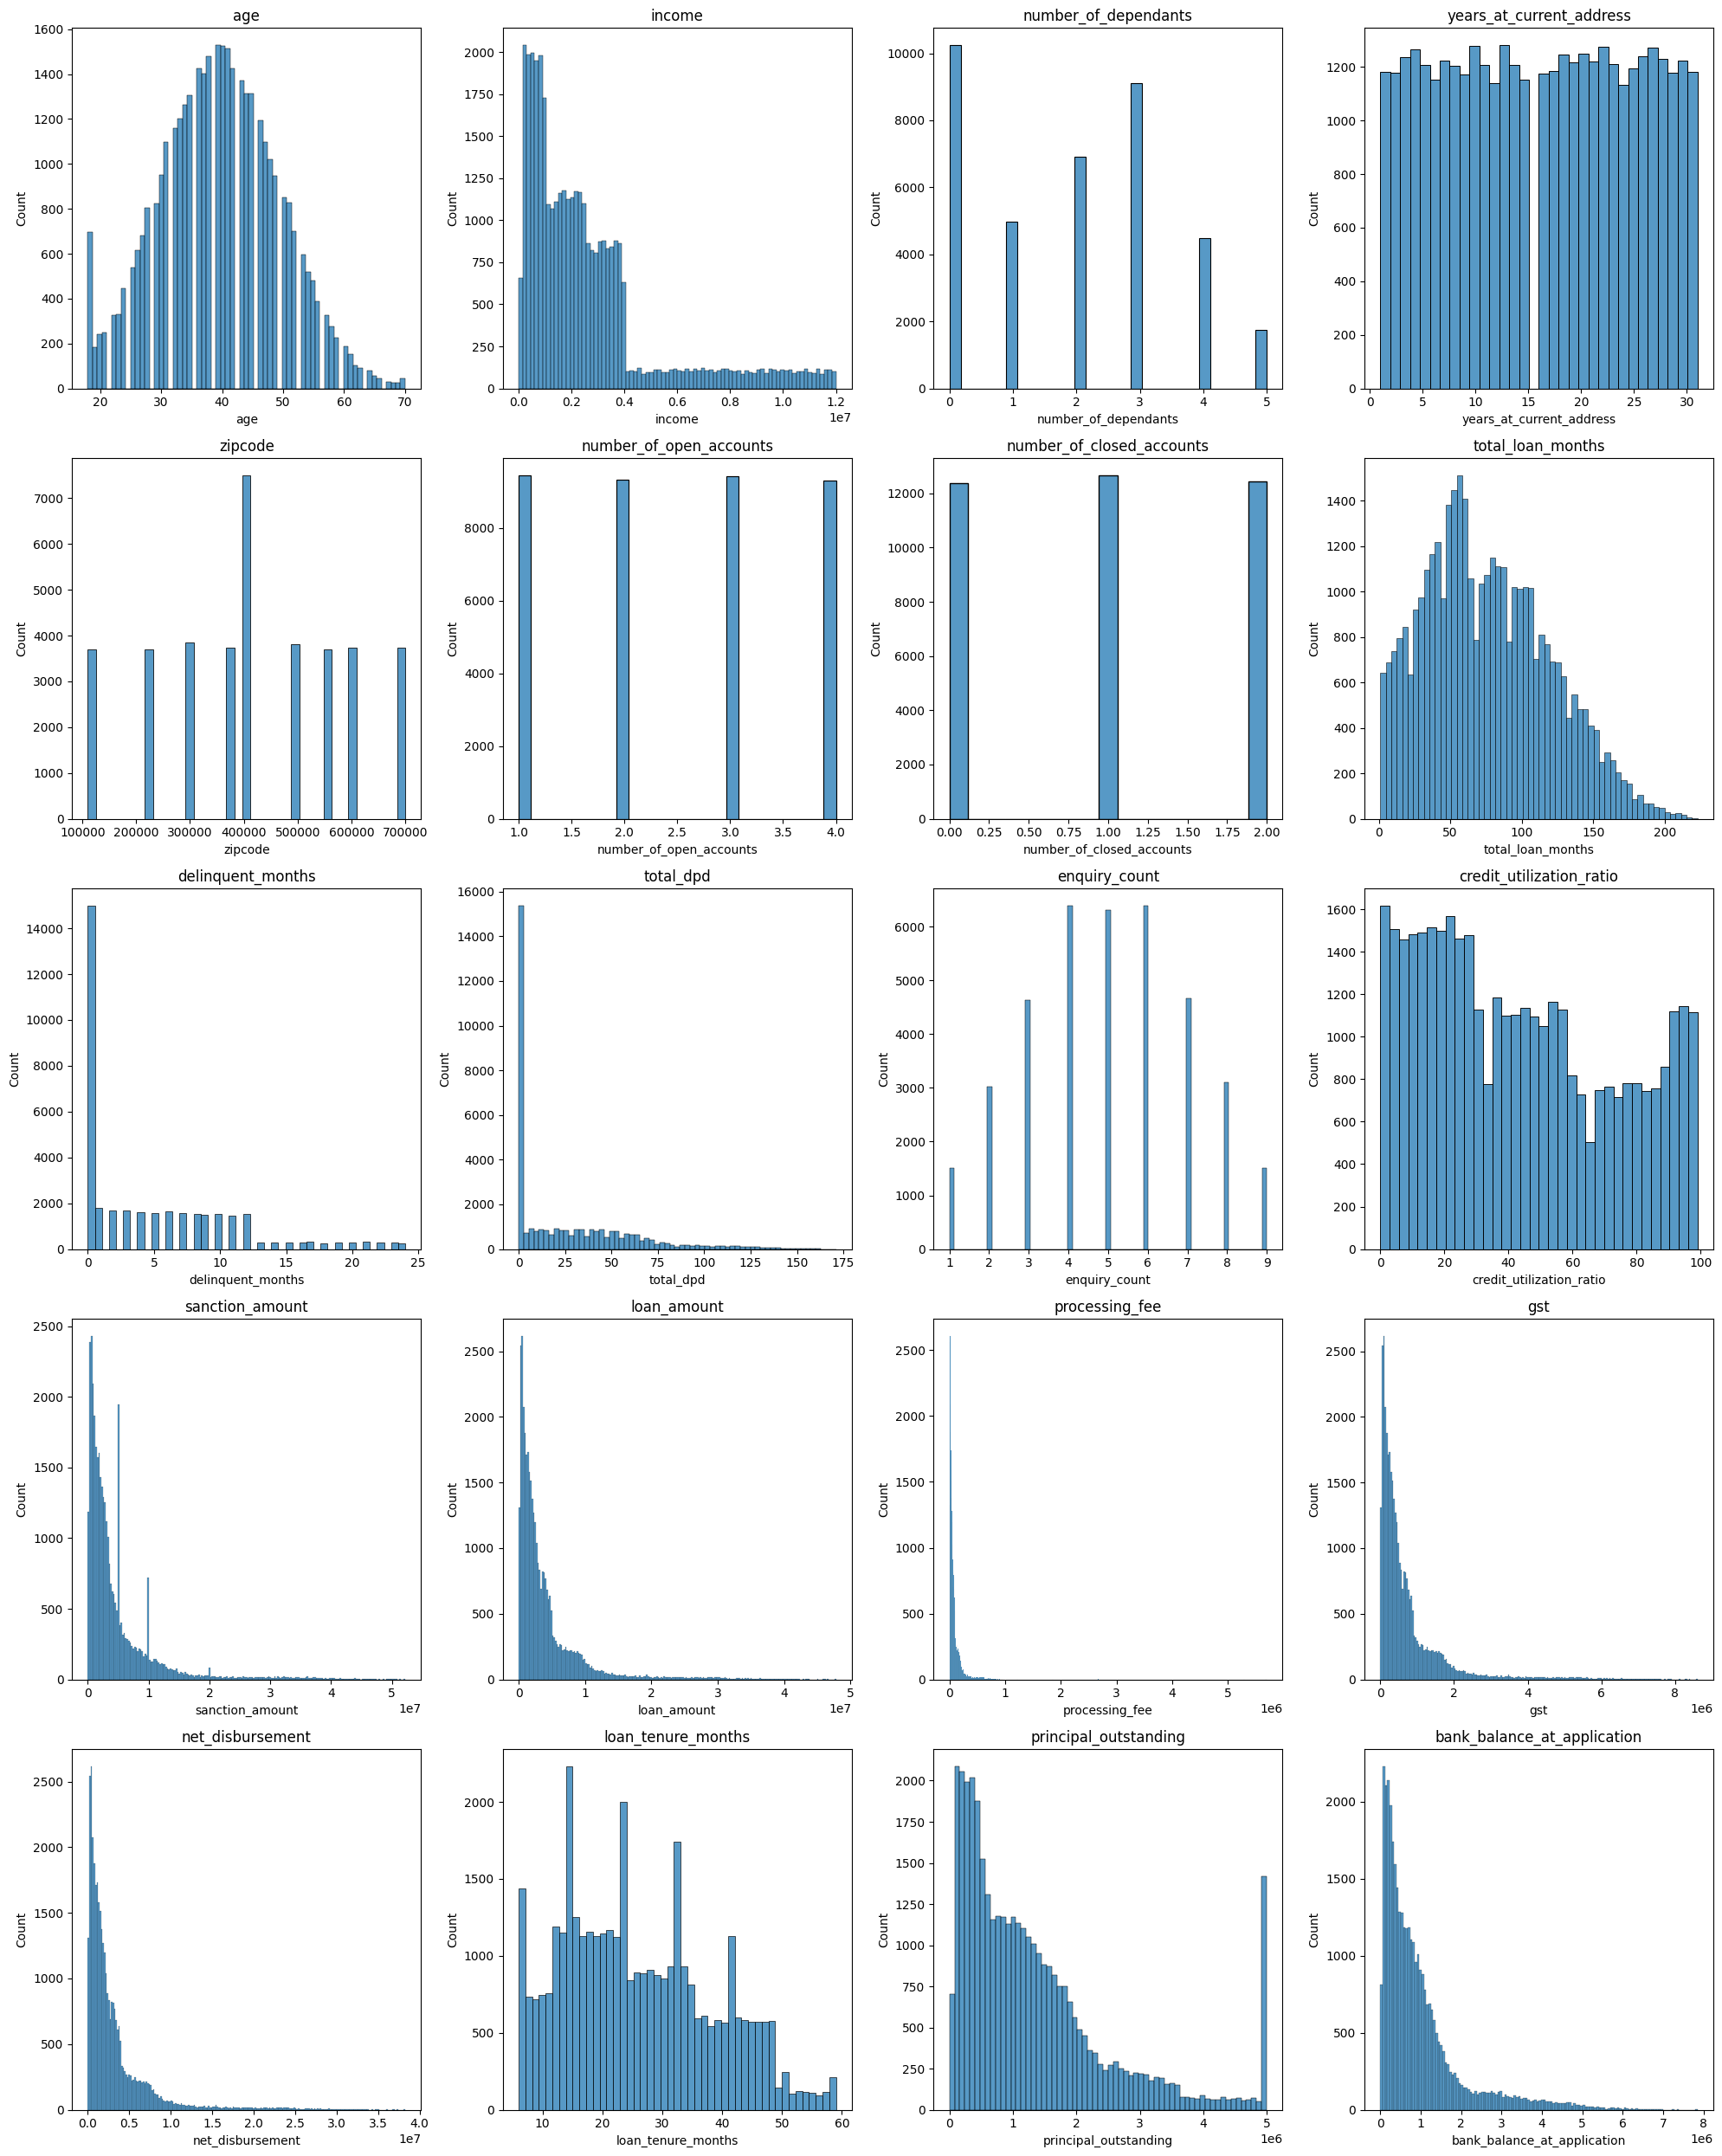

In [124]:
n_cols = 4
n_rows = math.ceil(len(columns_continuous)/n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()
for ax, col in zip(axes, columns_continuous):
    sns.histplot(x=df_train[col], ax=ax)
    ax.set_title(col)

# # Hide unused subplots
for ax in axes[len(columns_continuous):]:
    ax.set_visible(False)

plt.tight_layout()

A box plot is used to detect outliers using the IQR (Interquartile Range) method. The IQR method is a statistical technique that identifies values lying outside the lower and upper bounds. However, not all detected values are true outliers. If the values are valid and possible, they should be retained. If they are due to data entry errors, measurement errors, or are unrealistic, they should be treated or removed because they are considered true outliers.

This version makes an important distinction:

Statistical outliers → detected by the IQR method.

True outliers → values that are actually incorrect or abnormal based on domain knowledge.

A box plot only detects statistical outliers using the IQR rule. It does not determine whether those values are actually wrong. Domain knowledge is essential before deciding to remove or treat them.

<Axes: xlabel='loan_amount', ylabel='processing_fee'>

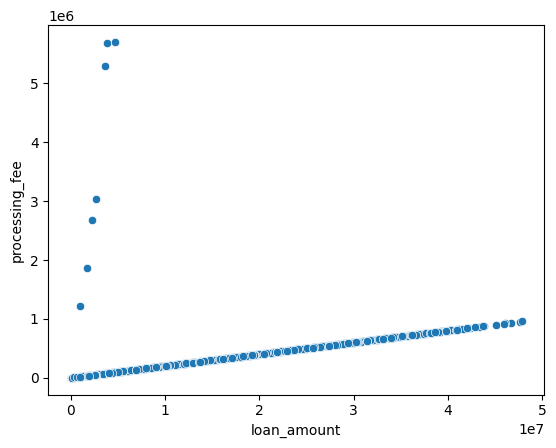

In [125]:
sns.scatterplot(x=df_train["loan_amount"], y=df_train["processing_fee"])

In [126]:
df_train[df_train["processing_fee"] >= df_train["loan_amount"]][['processing_fee','loan_amount']]

,processing_fee,loan_amount
29305,3.036378e+06,2616000
2278,0.000000e+00,0
47089,1.858965e+06,1738000
23981,2.669791e+06,2234000
33705,5.678021e+06,3812000
11092,0.000000e+00,0
47428,0.000000e+00,0
12294,5.698030e+06,4639000
13356,0.000000e+00,0
28174,1.214493e+06,966000


Point1 : A processing fee is the amount charged by a bank or financial institution for processing a loan application

Based on standard banking practice:

-- The fee is usually a set percentage of the total loan amount, ranging between 1% to 3%. 

-- A processing fee is usually a small percentage of the loan amount.

-- A processing fee larger than the loan amount is highly unusual and should be investigated.

Point2: GST is calculated only on the processing fee amount, not on the entire loan amount. 

-- GST is not grater than 18 % of processing fees.

-- A GST larger than 18% is highly unusal and should be investigated.

In [127]:
df_train[(df_train["processing_fee"] / df_train["loan_amount"])>0.03][['processing_fee','loan_amount']]

,processing_fee,loan_amount
29305,3.036378e+06,2616000
47089,1.858965e+06,1738000
23981,2.669791e+06,2234000
33705,5.678021e+06,3812000
12294,5.698030e+06,4639000
28174,1.214493e+06,966000
9898,5.293544e+06,3626000


In [128]:
df_train1 = df_train[(df_train["processing_fee"] / df_train["loan_amount"])<=0.03].copy()
df_train1[(df_train1["processing_fee"] / df_train1["loan_amount"])>0.03][['processing_fee','loan_amount']]

,processing_fee,loan_amount


In [129]:
# Apply same step on the test set 
df_test1 = df_test[(df_test["processing_fee"] / df_test["loan_amount"])<=0.03].copy()
df_test1[(df_test1["processing_fee"] / df_test1["loan_amount"])>0.03][['processing_fee','loan_amount']]

,processing_fee,loan_amount


In [130]:
df_train1[df_train1["gst"] > 0.18 * df_train1["sanction_amount"]]

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default


In [131]:
df_test1[df_test1["gst"] > 0.18 * df_test1["sanction_amount"]]

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default


<h3 style="color:green;">3.2 Categorical Column Cleaning</h3>

For numerical columns, we check for outliers because they contain continuous numerical values. However, for categorical columns, the concept of outliers is not meaningful since they represent categories rather than numerical measurements. Instead of checking for outliers, we analyze the frequency distribution of each category, identify rare categories, check for invalid or inconsistent category names, detect missing values, and ensure that each category is meaningful and correctly represented.

In [132]:
columns_categorical

['cust_id',
 'gender',
 'marital_status',
 'employment_status',
 'residence_type',
 'city',
 'state',
 'loan_id',
 'loan_purpose',
 'loan_type',
 'disbursal_date',
 'installment_start_dt']

In [133]:
for col in columns_categorical:
    print(col,"-->",df_train1[col].unique())

cust_id --> ['C23857' 'C48211' 'C01819' ... 'C00620' 'C26923' 'C47372']
gender --> ['F' 'M']
marital_status --> ['Single' 'Married']
employment_status --> ['Salaried' 'Self-Employed']
residence_type --> ['Mortgage' 'Owned' 'Rented']
city --> ['Delhi' 'Bangalore' 'Lucknow' 'Kolkata' 'Ahmedabad' 'Jaipur' 'Chennai'
 'Pune' 'Mumbai' 'Hyderabad']
state --> ['Delhi' 'Karnataka' 'Uttar Pradesh' 'West Bengal' 'Gujarat' 'Rajasthan'
 'Tamil Nadu' 'Maharashtra' 'Telangana']
loan_id --> ['L23857' 'L48211' 'L01819' ... 'L00620' 'L26923' 'L47372']
loan_purpose --> ['Auto' 'Home' 'Personal' 'Education' 'Personaal']
loan_type --> ['Secured' 'Unsecured']
disbursal_date --> ['2021-12-11' '2024-05-18' '2019-09-29' ... '2023-06-14' '2021-05-27'
 '2021-06-14']
installment_start_dt --> ['2021-12-19' '2024-06-15' '2019-10-29' ... '2019-08-06' '2023-09-16'
 '2019-07-25']


In [134]:
df_train1['loan_purpose'] = df_train1.loan_purpose.replace(to_replace='Personaal', value='Personal') 
df_test1['loan_purpose'] = df_test1.loan_purpose.replace(to_replace='Personaal', value='Personal')
df_train1.loan_purpose.unique()

array(['Auto', 'Home', 'Personal', 'Education'], dtype=object)

<h2 align="center" style="color:blue;"> 4. Exploratory Data Analysis (EDA)</h2>

In [135]:
columns_continuous

['age',
 'income',
 'number_of_dependants',
 'years_at_current_address',
 'zipcode',
 'number_of_open_accounts',
 'number_of_closed_accounts',
 'total_loan_months',
 'delinquent_months',
 'total_dpd',
 'enquiry_count',
 'credit_utilization_ratio',
 'sanction_amount',
 'loan_amount',
 'processing_fee',
 'gst',
 'net_disbursement',
 'loan_tenure_months',
 'principal_outstanding',
 'bank_balance_at_application']

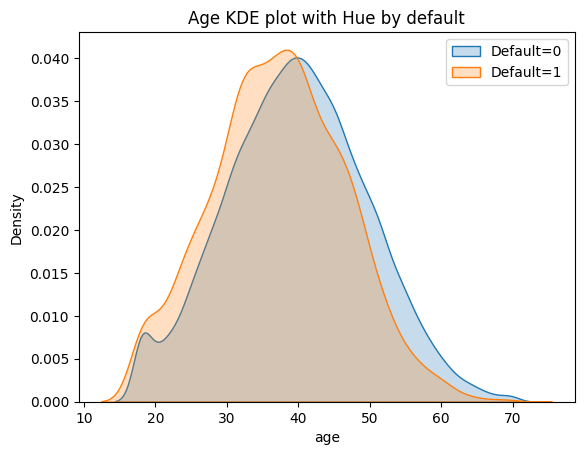

In [136]:
sns.kdeplot(df_train1[df_train1.default==0].age,fill=True, label="Default=0")
sns.kdeplot(df_train1[df_train1.default==1].age,fill=True, label="Default=1")
plt.title(f"Age KDE plot with Hue by default")
plt.legend()
plt.show()

Insights:
1. Orange graph is little bit shifted to the left of blue graph which indicates  that  people with young age are more likely to default

In [137]:
df_train1[df_train1.default==0].age

23856    40
1818     37
44684    53
39350    53
40326    45
         ..
36526    48
19340    36
619      42
26922    32
47371    28
Name: age, Length: 34266, dtype: int64

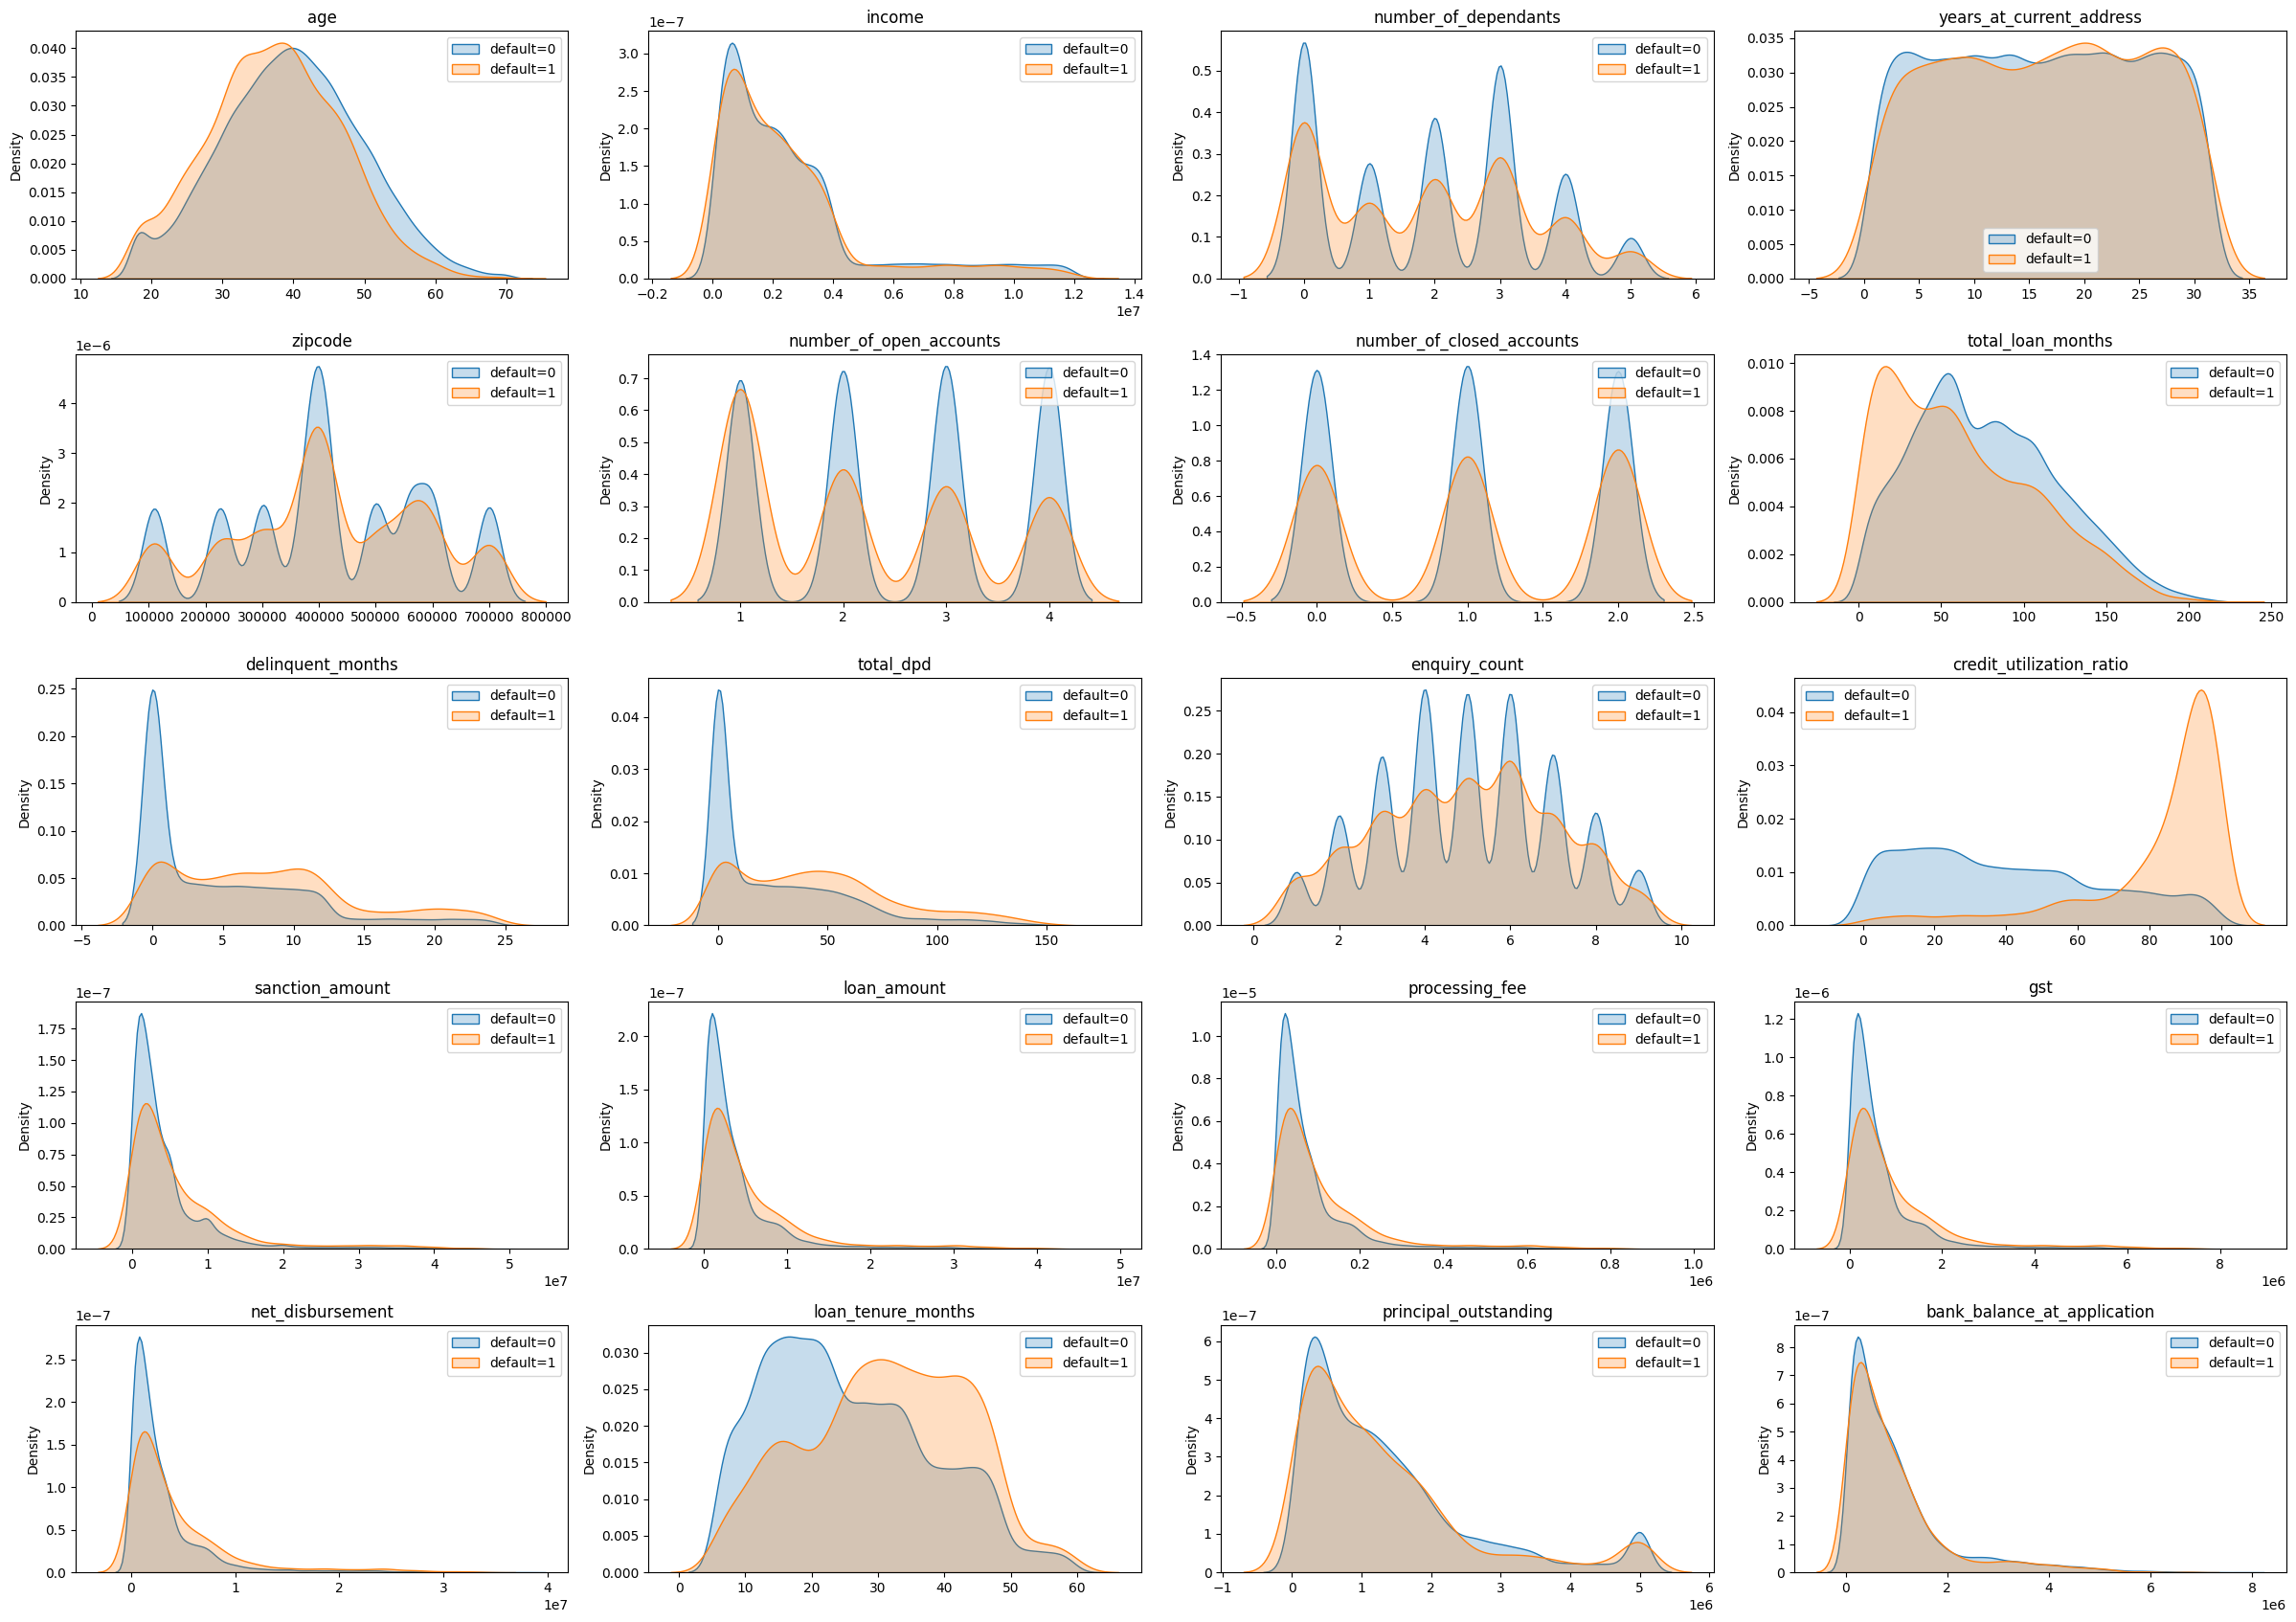

In [138]:
plt.figure(figsize=(24, 20))  # Width, height in inches

for i, col in enumerate(columns_continuous):
    plt.subplot(6, 4, i+1)  # 1 row, 4 columns, ith subplot
    sns.kdeplot(df_train1[col][df_train1['default']==0], fill=True, label='default=0')
    sns.kdeplot(df_train1[col][df_train1['default']==1], fill=True, label='default=1')
    plt.legend()
    plt.title(col)        
    plt.xlabel('')
    
plt.tight_layout()
plt.show()

**Insights**

1. In columns: loan_tenure_months, delinquent_months, total_dpd, credit_utilization, higher values indicate high likelyhood of becoming a default. Hence these 4 looks like strong predictors
1. In remaining columns the distributions do not give any obvious insights
1. Why loan_amount and income did not give any signs of being strong predictors? May be when we combine these two and get loan to income ratio (LTI), that may have influence on the target variable. We will explore more later

<h2 align="center" style="color:blue;"> 5.Feature Engineering</h2>

<h3 style="color:green;">5.1 Feature Creation</h3>

In [139]:
df_train1["loan_to_income"] = round(df_train1["loan_amount"]/df_train1["income"],2)
df_test1["loan_to_income"] = round(df_test1["loan_amount"]/df_test1["income"],2)

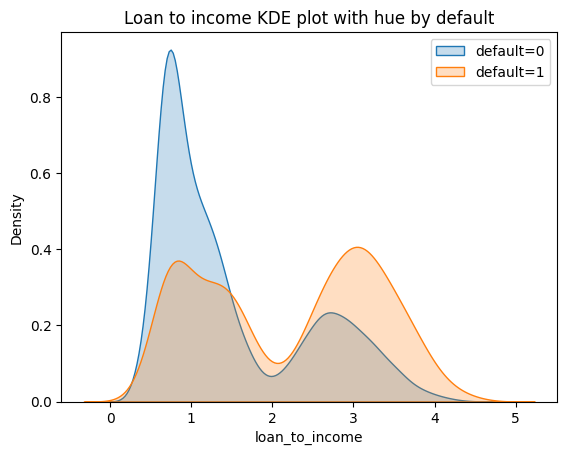

In [140]:
sns.kdeplot(df_train1[df_train1.default==0]["loan_to_income"], fill=True, label='default=0')
sns.kdeplot(df_train1[df_train1.default==1]["loan_to_income"], fill=True, label='default=1')
plt.title(f"Loan to income KDE plot with hue by default")
plt.legend()
plt.show()

People having a higher Loan-to-Income Ratio are more likely to default. That's why the Loan-to-Income Ratio is a strong predictor of loan default.

In [141]:
df_train1["delinquent_ratio"] = round(df_train1['delinquent_months']/df_train1['total_loan_months'],2)
df_test1["delinquent_ratio"] = round(df_test1['delinquent_months']/df_test1['total_loan_months'],2)

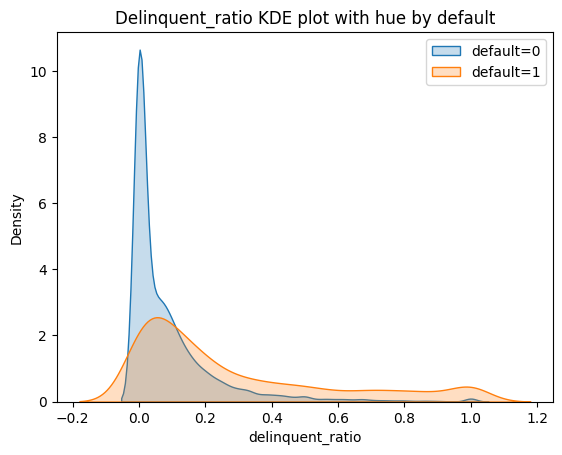

In [142]:
sns.kdeplot(df_train1[df_train1.default==0]["delinquent_ratio"], fill=True, label='default=0')
sns.kdeplot(df_train1[df_train1.default==1]["delinquent_ratio"], fill=True, label='default=1')
plt.title(f"Delinquent_ratio KDE plot with hue by default")
plt.legend()
plt.show()

People having a higher Delinquent Ratio are more likely to default. That's why the Delinquent Ratio is a strong predictor of loan default.

In [143]:
df_train1["avg_dpd_per_delinquency"] = np.where(
     df_train1["delinquent_months"]!=0,
     (df_train1["total_dpd"] / df_train1["delinquent_months"]).round(1),
     0
)
df_train1["avg_dpd_per_delinquency"] .describe()
df_train1["avg_dpd_per_delinquency"] .isna().sum()

0

In [144]:
df_test1["avg_dpd_per_delinquency"] = np.where(
     df_test1["delinquent_months"]!=0,
     (df_test1["total_dpd"] / df_test1["delinquent_months"]).round(1),
     0
)
df_test1["avg_dpd_per_delinquency"] .describe()
df_test1["avg_dpd_per_delinquency"] .isna().sum()

0

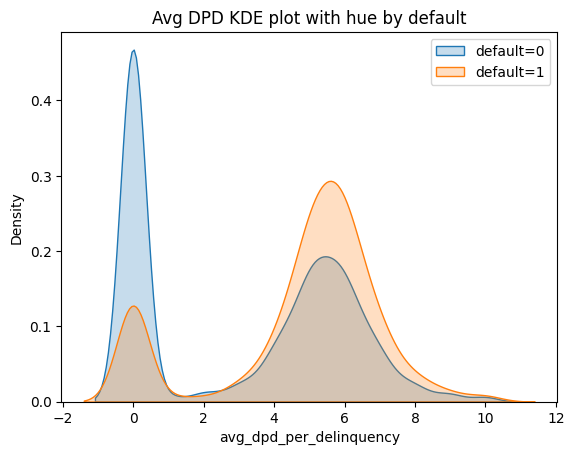

In [145]:
sns.kdeplot(df_train1[df_train1.default==0]["avg_dpd_per_delinquency"], fill=True, label='default=0')
sns.kdeplot(df_train1[df_train1.default==1]["avg_dpd_per_delinquency"], fill=True, label='default=1')
plt.title(f"Avg DPD KDE plot with hue by default")
plt.legend()
plt.show()

People having a higher average value of DPD  are likely to default. That's why the average DPD per delinquency is a strong predictor of loan default.

<h3 style="color:green;">5.2 Feature Selection</h3>

In [146]:
df_train1.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count',
       'credit_utilization_ratio', 'loan_id', 'loan_purpose', 'loan_type',
       'sanction_amount', 'loan_amount', 'processing_fee', 'gst',
       'net_disbursement', 'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'disbursal_date', 'installment_start_dt',
       'default', 'loan_to_income', 'delinquent_ratio',
       'avg_dpd_per_delinquency'],
      dtype='object')

In [147]:
df_train2 = df_train1.drop(["cust_id", "loan_id"], axis="columns")
df_test2 = df_test1.drop(["cust_id", "loan_id"], axis="columns")                          

In [148]:
df_train3 = df_train2.drop(['disbursal_date', 'installment_start_dt', 'loan_amount', 'income', 
                              'total_loan_months', 'delinquent_months', 'total_dpd'], axis="columns")
df_test3 = df_test2.drop(['disbursal_date', 'installment_start_dt', 'loan_amount', 'income', 
                              'total_loan_months', 'delinquent_months', 'total_dpd'], axis="columns")
df_train3.columns

Index(['age', 'gender', 'marital_status', 'employment_status',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_purpose', 'loan_type',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'default', 'loan_to_income',
       'delinquent_ratio', 'avg_dpd_per_delinquency'],
      dtype='object')

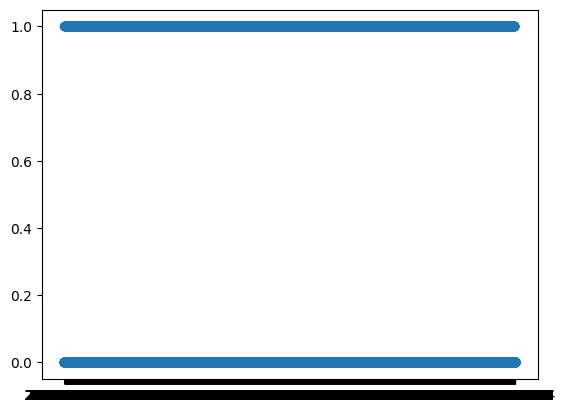

In [149]:
plt.scatter(x=df_train2['disbursal_date'],y=df_train2['default'])

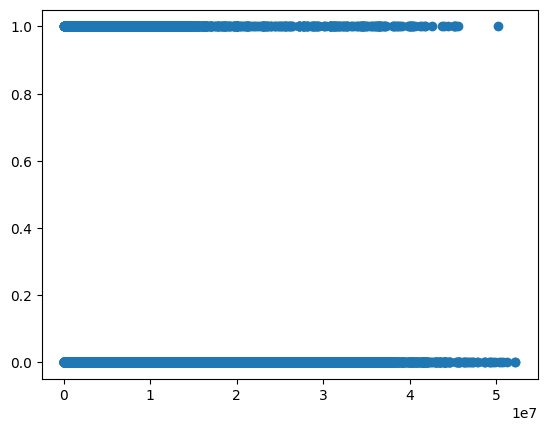

In [150]:
plt.scatter(x=df_train2['sanction_amount'],y=df_train2['default'])

In [151]:
df_train3.select_dtypes(['int64','float64']).info()

<class 'pandas.core.frame.DataFrame'>
Index: 37489 entries, 23856 to 47371
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          37489 non-null  int64  
 1   number_of_dependants         37489 non-null  int64  
 2   years_at_current_address     37489 non-null  int64  
 3   zipcode                      37489 non-null  int64  
 4   number_of_open_accounts      37489 non-null  int64  
 5   number_of_closed_accounts    37489 non-null  int64  
 6   enquiry_count                37489 non-null  int64  
 7   credit_utilization_ratio     37489 non-null  int64  
 8   sanction_amount              37489 non-null  int64  
 9   processing_fee               37489 non-null  float64
 10  gst                          37489 non-null  int64  
 11  net_disbursement             37489 non-null  int64  
 12  loan_tenure_months           37489 non-null  int64  
 13  principal_outstan

In [152]:
X_train = df_train3.drop('default', axis=1)
y_train = df_train3['default']

from sklearn.preprocessing import MinMaxScaler


cols_to_scale = X_train.select_dtypes(include=['int64', 'float64']).columns

scaler = MinMaxScaler()



X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

X_train.describe()

,age,number_of_dependants,years_at_current_address,zipcode,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,loan_to_income,delinquent_ratio,avg_dpd_per_delinquency
count,37489.000000,37489.000000,37489.000000,37489.000000,37489.000000,37489.000000,37489.000000,37489.000000,37489.000000,37489.000000,37489.000000,37489.000000,37489.000000,37489.000000,37489.000000,37489.000000,37489.000000,37489.000000
mean,0.414358,0.388733,0.500775,0.523743,0.498502,0.500880,0.501104,0.438114,0.089069,0.082722,0.082722,0.082722,0.376056,0.262717,0.124084,0.292712,0.104386,0.330042
std,0.189672,0.307630,0.297915,0.286101,0.372676,0.406938,0.252632,0.296555,0.119839,0.112073,0.112073,0.112073,0.234282,0.244263,0.133789,0.226571,0.173060,0.290437
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.288462,0.000000,0.233333,0.325424,0.000000,0.000000,0.375000,0.181818,0.020632,0.019094,0.019094,0.019094,0.188679,0.078474,0.034274,0.109557,0.000000,0.000000
50%,0.403846,0.400000,0.500000,0.491525,0.333333,0.500000,0.500000,0.393939,0.049901,0.045914,0.045914,0.045914,0.339623,0.195536,0.083393,0.200466,0.040000,0.430000
75%,0.538462,0.600000,0.766667,0.762712,0.666667,1.000000,0.625000,0.676768,0.099457,0.095890,0.095890,0.095890,0.547170,0.354674,0.156085,0.501166,0.130000,0.570000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [153]:
X_test = df_test3.drop('default', axis=1)
y_test = df_test3['default']

X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
X_test.describe()

,age,number_of_dependants,years_at_current_address,zipcode,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,loan_to_income,delinquent_ratio,avg_dpd_per_delinquency
count,12496.000000,12496.000000,12496.000000,12496.000000,12496.000000,12496.000000,12496.000000,12496.000000,12496.000000,12496.000000,12496.000000,12496.000000,12496.000000,12496.000000,12496.000000,12496.000000,12496.000000,12496.000000
mean,0.414647,0.385403,0.500125,0.524337,0.504561,0.499480,0.501390,0.437654,0.088531,0.082172,0.082172,0.082172,0.376815,0.261325,0.123342,0.292354,0.102905,0.328893
std,0.188525,0.305528,0.296457,0.287350,0.373642,0.407439,0.256697,0.296469,0.121668,0.114085,0.114085,0.114085,0.235526,0.245893,0.133175,0.226317,0.173006,0.290397
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000019,-0.000126,-0.000126,-0.000126,0.000000,0.000163,0.000216,0.000000,0.000000,0.000000
25%,0.288462,0.000000,0.233333,0.325424,0.333333,0.000000,0.375000,0.181818,0.020651,0.019005,0.019005,0.019005,0.188679,0.078509,0.033891,0.109557,0.000000,0.000000
50%,0.423077,0.400000,0.500000,0.491525,0.666667,0.500000,0.500000,0.393939,0.048874,0.045119,0.045119,0.045119,0.339623,0.191825,0.081589,0.200466,0.040000,0.430000
75%,0.538462,0.600000,0.766667,0.762712,1.000000,1.000000,0.750000,0.676768,0.094582,0.093817,0.093817,0.093817,0.547170,0.351066,0.154965,0.501166,0.130000,0.580000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.981249,0.986475,0.986475,0.986475,1.000000,1.000000,0.945405,0.995338,1.000000,1.000000


In [154]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [155]:
calculate_vif(X_train[cols_to_scale])

C:\Users\suman\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Column,VIF
0,age,5.714483
1,number_of_dependants,2.732889
2,years_at_current_address,3.418673
3,zipcode,3.804839
4,number_of_open_accounts,4.334004
5,number_of_closed_accounts,2.387592
6,enquiry_count,6.406722
7,credit_utilization_ratio,2.932072
8,sanction_amount,100.955721
9,processing_fee,inf


In [156]:
features_to_drop_vif = ['sanction_amount','processing_fee','gst','net_disbursement','principal_outstanding']
X_train1 = X_train.drop(features_to_drop_vif, axis='columns')
X_test1 = X_test.drop(features_to_drop_vif, axis='columns')

In [157]:
numeric_features = X_train1.select_dtypes(include=['int64', 'float64']).columns

In [158]:
vif_df = calculate_vif(X_train1[numeric_features ])

In [159]:
selceted_numeric_feature_vif = vif_df.Column.values
selceted_numeric_feature_vif 

array(['age', 'number_of_dependants', 'years_at_current_address',
       'zipcode', 'number_of_open_accounts', 'number_of_closed_accounts',
       'enquiry_count', 'credit_utilization_ratio', 'loan_tenure_months',
       'bank_balance_at_application', 'loan_to_income',
       'delinquent_ratio', 'avg_dpd_per_delinquency'], dtype=object)

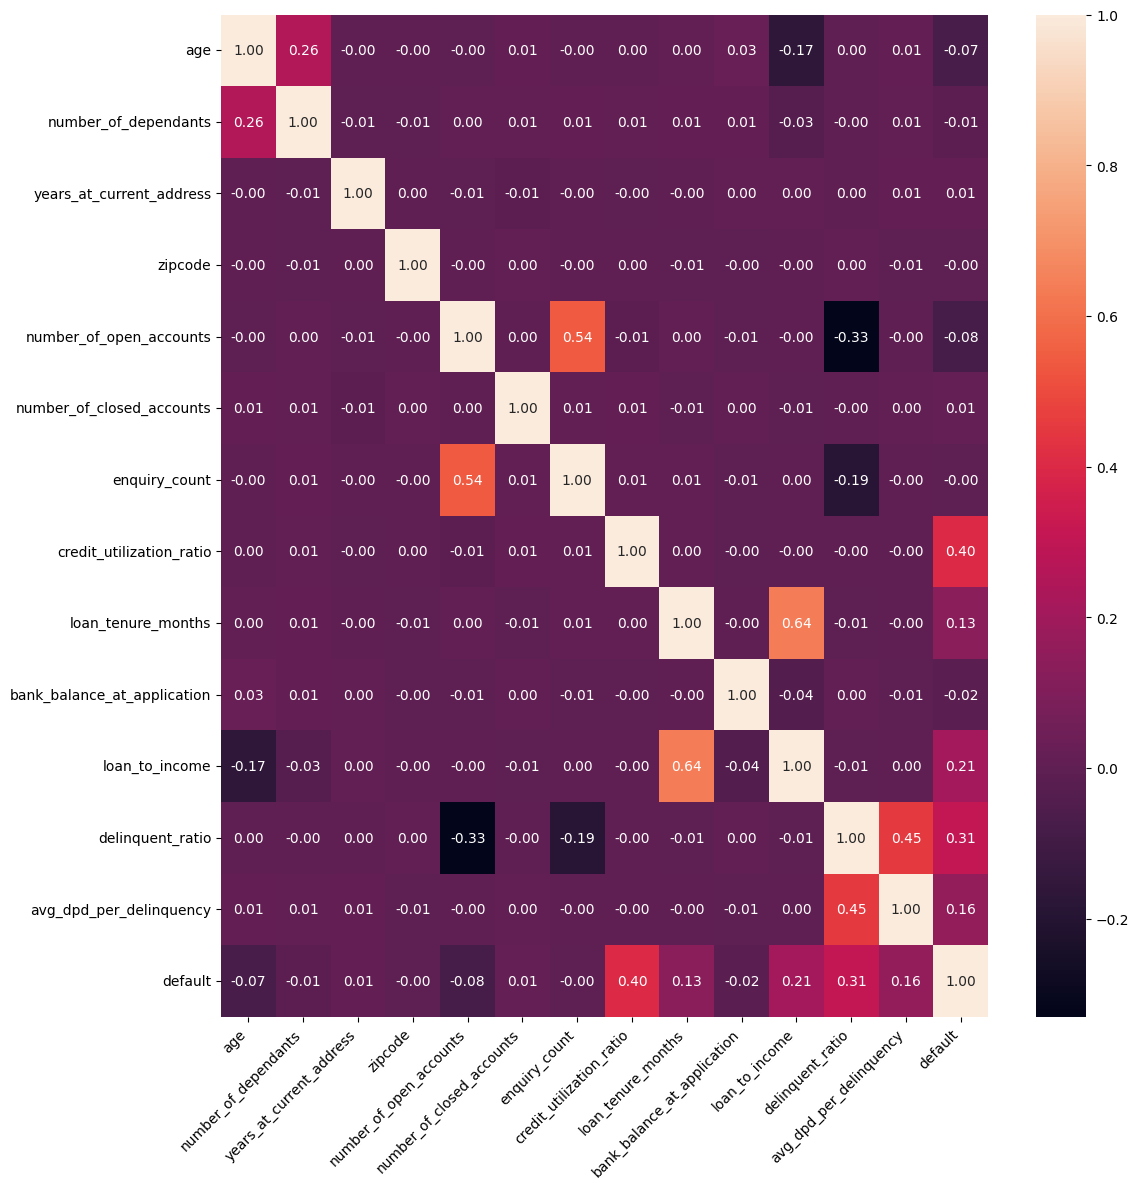

In [160]:
plt.figure(figsize=(12,12))
cm = df_train3[numeric_features.append(pd.Index(['default']))].corr()
sns.heatmap(cm, annot=True, fmt='0.2f')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [161]:
columns_categorical

['cust_id',
 'gender',
 'marital_status',
 'employment_status',
 'residence_type',
 'city',
 'state',
 'loan_id',
 'loan_purpose',
 'loan_type',
 'disbursal_date',
 'installment_start_dt']

In [162]:
def calculate_woe_iv(df, feature ,target):
    grouped = df.groupby(feature)[target].agg(['count','sum'])
    grouped = grouped.rename(columns={'count': 'total', 'sum': 'good'})
    grouped['bad'] = grouped['total'] - grouped['good']
    
    grouped['Default(Good)'] = grouped['good'] / np.sum(grouped.good)
    grouped['Not Default(bad)'] = grouped['bad'] / np.sum(grouped.bad)

    grouped['woe'] = np.log( grouped['Default(Good)'] / grouped['Not Default(bad)'])
    grouped['iv'] = grouped['woe'] * (grouped['Default(Good)'] - grouped['Not Default(bad)'] )

    grouped['woe'] = grouped['woe'].replace([np.inf, -np.inf],0)
    grouped['iv'] = grouped['iv'].replace([np.inf, -np.inf],0)

    total_iv = grouped['iv'].sum()
    return grouped,total_iv

In [163]:
iv_values = {}
for column in  X_train1.columns:
    if X_train1[column].dtypes == 'object':
        
          _,total_iv = calculate_woe_iv(pd.concat([X_train1,y_train],axis=1), column ,"default")
          
    else:
        
          X_binned = pd.cut(X_train1[column], bins=10, labels=False)
          _,total_iv = calculate_woe_iv(pd.concat([ X_binned,y_train],axis=1), column ,"default")

    iv_values[column] = total_iv

          
        
        
        
iv_values

C:\Users\suman\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


{'age': 0.07551872264536666,
 'gender': 0.00013772529845376534,
 'marital_status': 0.003421053686820354,
 'employment_status': 0.0014336327280566438,
 'number_of_dependants': 0.004096405892268551,
 'residence_type': 0.255997355667298,
 'years_at_current_address': 0.0018773098006593172,
 'city': 0.0023253736873865135,
 'state': 0.002281827114449444,
 'zipcode': 0.002325193205842839,
 'number_of_open_accounts': 0.09506007740964662,
 'number_of_closed_accounts': 0.0021199038089097393,
 'enquiry_count': 0.01059883922285095,
 'credit_utilization_ratio': 2.396003690059465,
 'loan_purpose': 0.3950948884727373,
 'loan_type': 0.17608563089183438,
 'loan_tenure_months': 0.2395667175806681,
 'bank_balance_at_application': 0.0068874410254387754,
 'loan_to_income': 0.4919221996399515,
 'delinquent_ratio': 0.7011926628282709,
 'avg_dpd_per_delinquency': 0.40597466571001356}

In [164]:
iv_df = pd.DataFrame(data = iv_values.items(),columns=['Feature', 'IV'])
iv_df = iv_df.sort_values(by='IV', ascending=False)
iv_df

,Feature,IV
13,credit_utilization_ratio,2.396004
19,delinquent_ratio,0.701193
18,loan_to_income,0.491922
20,avg_dpd_per_delinquency,0.405975
14,loan_purpose,0.395095
5,residence_type,0.255997
16,loan_tenure_months,0.239567
15,loan_type,0.176086
10,number_of_open_accounts,0.095060
0,age,0.075519


In [165]:
selected_features_iv = iv_df[iv_df['IV']>0.02]['Feature'].values
selected_features_iv

array(['credit_utilization_ratio', 'delinquent_ratio', 'loan_to_income',
       'avg_dpd_per_delinquency', 'loan_purpose', 'residence_type',
       'loan_tenure_months', 'loan_type', 'number_of_open_accounts',
       'age'], dtype=object)

<h3 style="color:green;">5.3 Feature Encoding</h3>

In [166]:
X_train_reduced = X_train1[selected_features_iv] 
X_test_reduced = X_test1[selected_features_iv]  

In [167]:
X_test_reduced.describe()

,credit_utilization_ratio,delinquent_ratio,loan_to_income,avg_dpd_per_delinquency,loan_tenure_months,number_of_open_accounts,age
count,12496.000000,12496.000000,12496.000000,12496.000000,12496.000000,12496.000000,12496.000000
mean,0.437654,0.102905,0.292354,0.328893,0.376815,0.504561,0.414647
std,0.296469,0.173006,0.226317,0.290397,0.235526,0.373642,0.188525
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.181818,0.000000,0.109557,0.000000,0.188679,0.333333,0.288462
50%,0.393939,0.040000,0.200466,0.430000,0.339623,0.666667,0.423077
75%,0.676768,0.130000,0.501166,0.580000,0.547170,1.000000,0.538462
max,1.000000,1.000000,0.995338,1.000000,1.000000,1.000000,1.000000


In [168]:
X_train_reduced.describe()

,credit_utilization_ratio,delinquent_ratio,loan_to_income,avg_dpd_per_delinquency,loan_tenure_months,number_of_open_accounts,age
count,37489.000000,37489.000000,37489.000000,37489.000000,37489.000000,37489.000000,37489.000000
mean,0.438114,0.104386,0.292712,0.330042,0.376056,0.498502,0.414358
std,0.296555,0.173060,0.226571,0.290437,0.234282,0.372676,0.189672
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.181818,0.000000,0.109557,0.000000,0.188679,0.000000,0.288462
50%,0.393939,0.040000,0.200466,0.430000,0.339623,0.333333,0.403846
75%,0.676768,0.130000,0.501166,0.570000,0.547170,0.666667,0.538462
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [169]:
X_train_encoded = pd.get_dummies(X_train_reduced, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_reduced, drop_first=True)

X_train_encoded.head()

,credit_utilization_ratio,delinquent_ratio,loan_to_income,avg_dpd_per_delinquency,loan_tenure_months,number_of_open_accounts,age,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,residence_type_Owned,residence_type_Rented,loan_type_Unsecured
23856,0.989899,0.19,0.202797,0.45,0.320755,0.000000,0.423077,False,False,False,False,False,False
48210,0.868687,0.02,0.564103,0.45,0.773585,1.000000,0.288462,False,True,False,False,False,False
1818,0.656566,0.00,0.074592,0.00,0.037736,1.000000,0.365385,False,False,True,False,False,True
44684,0.282828,0.08,0.447552,0.56,0.716981,1.000000,0.673077,False,True,False,True,False,False
39350,0.575758,0.00,0.428904,0.00,0.396226,0.666667,0.673077,False,True,False,True,False,False


<h2 align="center" style="color:blue;">6. Model Training</h2>

<h3 style="color:green;">6.1 Attempt1</h3>

    1.Logistic RegressIon, Random Forest & XGB
    2.No handling of class imbalance 

In [170]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression()
model.fit(X_train_encoded,y_train )
y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11422
           1       0.84      0.70      0.76      1074

    accuracy                           0.96     12496
   macro avg       0.90      0.85      0.87     12496
weighted avg       0.96      0.96      0.96     12496



In [171]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train_encoded,y_train )
y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11422
           1       0.82      0.70      0.76      1074

    accuracy                           0.96     12496
   macro avg       0.90      0.84      0.87     12496
weighted avg       0.96      0.96      0.96     12496



In [172]:
from xgboost import XGBClassifier

model =  XGBClassifier()
model.fit(X_train_encoded,y_train )
y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11422
           1       0.79      0.73      0.76      1074

    accuracy                           0.96     12496
   macro avg       0.88      0.86      0.87     12496
weighted avg       0.96      0.96      0.96     12496



<h3 style="color:green;">---- RandomizedSearch CV for Attempt 1: Logistic Regression</h3>

In [173]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'C': np.logspace(-4, 4, 20),  # Logarithmically spaced values from 10^-4 to 10^4
    'solver': ['lbfgs', 'saga', 'liblinear', 'newton-cg']   # Algorithm to use in the optimization problem
}

# Create the Logistic Regression model
log_reg = LogisticRegression(max_iter=10000)  # Increased max_iter for convergence

# Set up RandomizedSearchCV
random_search1 = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=50,  # Number of parameter settings that are sampled
    scoring='f1',
    cv=3,  # 3-fold cross-validation
    verbose=2,
    random_state=42,  # Set a random state for reproducibility
    n_jobs=-1  # Use all available cores
)

# Fit the RandomizedSearchCV to the training data
random_search1.fit(X_train_encoded, y_train)

# Print the best parameters and best score
print(f"Best Parameters: {random_search1.best_params_}")
print(f"Best Score: {random_search1.best_score_}")

best_model = random_search1.best_estimator_
y_pred = best_model.predict(X_test_encoded)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'solver': 'saga', 'C': 206.913808111479}
Best Score: 0.7613604676083167
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11422
           1       0.82      0.72      0.77      1074

    accuracy                           0.96     12496
   macro avg       0.90      0.85      0.87     12496
weighted avg       0.96      0.96      0.96     12496



<h3 style="color:green;">---- RandomizedSearch CV for Attempt 1: XGBoost</h3>

In [174]:
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV

# Define parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'scale_pos_weight': [1, 2, 3, 5, 7, 10],
    'reg_alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],  # L1 regularization term
    'reg_lambda': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]  # L2 regularization term
}

xgb = XGBClassifier()

random_search2 = RandomizedSearchCV(estimator=xgb, param_distributions=param_dist, n_iter=100,
                                   scoring='f1', cv=3, verbose=1, n_jobs=-1, random_state=42)

random_search2.fit(X_train_encoded, y_train)

# Print the best parameters and best score
print(f"Best Parameters: {random_search2.best_params_}")
print(f"Best Score: {random_search2.best_score_}")

best_model = random_search2.best_estimator_
y_pred = best_model.predict(X_test_encoded)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best Parameters: {'subsample': 0.8, 'scale_pos_weight': 2, 'reg_lambda': 1.0, 'reg_alpha': 5.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.9}
Best Score: 0.7914031107555314
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11422
           1       0.76      0.83      0.80      1074

    accuracy                           0.96     12496
   macro avg       0.87      0.90      0.89     12496
weighted avg       0.96      0.96      0.96     12496



<h3 style="color:green;">6.2 Attempt2</h3>

1. Logistic Regression & XGB
1. Handle Class Imbalance Using Under Sampling

In [175]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train_encoded, y_train)
y_train_res.value_counts()

default
0    3223
1    3223
Name: count, dtype: int64

<h3 style="color:green;">----- RandomizedSearch CV for Attempt 2: Logistic Regression </h3>

In [176]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'C': np.logspace(-4, 4, 20),  # Logarithmically spaced values from 10^-4 to 10^4
    'solver': ['lbfgs', 'saga', 'liblinear', 'newton-cg']   # Algorithm to use in the optimization problem
}

# Create the Logistic Regression model
log_reg = LogisticRegression(max_iter=10000)  # Increased max_iter for convergence

# Set up RandomizedSearchCV
random_search1 = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=50,  # Number of parameter settings that are sampled
    scoring='f1',
    cv=3,  # 3-fold cross-validation
    verbose=2,
    random_state=42,  # Set a random state for reproducibility
    n_jobs=-1  # Use all available cores
)

# Fit the RandomizedSearchCV to the training data
random_search1.fit(X_train_res, y_train_res)

# Print the best parameters and best score
print(f"Best Parameters: {random_search1.best_params_}")
print(f"Best Score: {random_search1.best_score_}")

best_model = random_search1.best_estimator_
y_pred = best_model.predict(X_test_encoded)
print("Classification Report:")
print(classification_report(y_test, y_pred))      

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'solver': 'newton-cg', 'C': 29.763514416313132}
Best Score: 0.9412182248532063
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.92      0.96     11422
           1       0.54      0.95      0.68      1074

    accuracy                           0.93     12496
   macro avg       0.77      0.93      0.82     12496
weighted avg       0.96      0.93      0.93     12496



<h3 style="color:green;">----- RandomizedSearch CV for Attempt 2: XGBoost</h3

In [177]:
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV

# Define parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'scale_pos_weight': [1, 2, 3, 5, 7, 10],
    'reg_alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],  # L1 regularization term
    'reg_lambda': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]  # L2 regularization term
}

xgb = XGBClassifier()

random_search2 = RandomizedSearchCV(estimator=xgb, param_distributions=param_dist, n_iter=100,
                                   scoring='f1', cv=3, verbose=1, n_jobs=-1, random_state=42)

random_search2.fit(X_train_res, y_train_res)

# Print the best parameters and best score
print(f"Best Parameters: {random_search2.best_params_}")
print(f"Best Score: {random_search2.best_score_}")

best_model = random_search2.best_estimator_
y_pred = best_model.predict(X_test_encoded)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best Parameters: {'subsample': 0.8, 'scale_pos_weight': 2, 'reg_lambda': 1.0, 'reg_alpha': 5.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.9}
Best Score: 0.9488631493969982
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95     11422
           1       0.51      0.98      0.67      1074

    accuracy                           0.92     12496
   macro avg       0.75      0.95      0.81     12496
weighted avg       0.96      0.92      0.93     12496



<h3 style="color:green;">6.3 Attempt3</h3
                                             
    1. Logistic Regression
    2. Handle Class Imbalance Using SMOTE Tomek
    3. Parameter tunning using optuna

In [178]:
from imblearn.combine import SMOTETomek

smt = SMOTETomek(random_state=42)
X_train_smt, y_train_smt = smt.fit_resample(X_train_encoded, y_train)
y_train_smt.value_counts()

default
0    34198
1    34198
Name: count, dtype: int64

### 1.Optuna employs advanced techniques such as Gradient Optimization,Bayesian Optimization, and Evolutionary algorithms to efficiently identify the optimal parameters.
### 2.Compared to Hyperparameter Tuning methods like GridSearchCV and RandomizedSearchCV,Optuna offers a more effective solution.  


In [179]:
import optuna
from sklearn.metrics import make_scorer ,f1_score
from sklearn.model_selection import cross_val_score

In [180]:
# Define the objective function for Optuna
def objective(trial):
    param = {
        'C': trial.suggest_float('C', 1e-4, 1e4, log=True),  # Logarithmically spaced values
        'solver': trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga', 'newton-cg']),  # Solvers
        'tol': trial.suggest_float('tol', 1e-6, 1e-1, log=True),  # Logarithmically spaced values for tolerance
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])  # Class weights
    }

    model = LogisticRegression(**param, max_iter=10000)
    
    # Calculate the cross-validated f1_score
    f1_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X_train_smt, y_train_smt, cv=3, scoring=f1_scorer, n_jobs=-1)
    
    return np.mean(scores)

study_logistic = optuna.create_study(direction='maximize')
study_logistic.optimize(objective, n_trials=50)

[I 2026-07-26 21:19:33,586] A new study created in memory with name: no-name-cb99b205-6a7c-4e15-a3c0-f307f608d1f9
[I 2026-07-26 21:19:33,854] Trial 0 finished with value: 0.9319938428910071 and parameters: {'C': 0.017474476178082777, 'solver': 'newton-cg', 'tol': 9.374144609575007e-05, 'class_weight': None}. Best is trial 0 with value: 0.9319938428910071.
[I 2026-07-26 21:19:34,148] Trial 1 finished with value: 0.9444444192682168 and parameters: {'C': 0.5696887635697808, 'solver': 'liblinear', 'tol': 0.008629537179361118, 'class_weight': None}. Best is trial 1 with value: 0.9444444192682168.
[I 2026-07-26 21:19:34,368] Trial 2 finished with value: 0.8563664999692907 and parameters: {'C': 0.00025489865404639, 'solver': 'newton-cg', 'tol': 0.0010569546183183994, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.9444444192682168.
[I 2026-07-26 21:19:34,711] Trial 3 finished with value: 0.9461211294442755 and parameters: {'C': 1981.8360777595415, 'solver': 'newton-cg', 'tol': 0.00

In [181]:
print("Best trial")
trial = study_logistic.best_trial
print('F1-score:{}'.format(trial.value))
print('Params:')
for key ,value in trial.params.items():
    print('    {}: {}'.format(key, value))
    
best_model_logistic = LogisticRegression(**study_logistic.best_params)
best_model_logistic.fit(X_train_smt, y_train_smt)
y_pred = best_model_logistic.predict(X_test_encoded)

report = classification_report(y_test, y_pred)
print(report)

Best trial
F1-score:0.9464755173840779
Params:
    C: 12.994172577299356
    solver: saga
    tol: 0.09617157243190969
    class_weight: None
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11422
           1       0.56      0.94      0.70      1074

    accuracy                           0.93     12496
   macro avg       0.78      0.93      0.83     12496
weighted avg       0.96      0.93      0.94     12496



<h3 style="color:green;">6.3 Attempt4</h3

1. XGBoost
1. Handle Class Imbalance Using SMOTE Tomek
1. Parameter tunning using optuna

In [182]:
# Define the objective function for Optuna
def objective(trial):
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'verbosity': 0,
        'booster': 'gbtree',
        'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'eta': trial.suggest_float('eta', 0.01, 0.3),
        'gamma': trial.suggest_float('gamma', 0, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'max_delta_step': trial.suggest_int('max_delta_step', 0, 10)
    }

    model = XGBClassifier(**param)
    
    # Calculate the cross-validated f1_score
    f1_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X_train_smt, y_train_smt, cv=3, scoring=f1_scorer, n_jobs=-1)
    
    return np.mean(scores)

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective, n_trials=50)

[I 2026-07-26 21:19:48,344] A new study created in memory with name: no-name-5a07ffc8-3e17-462f-9adf-f95c64968f13
[I 2026-07-26 21:19:49,887] Trial 0 finished with value: 0.9741158686223882 and parameters: {'lambda': 1.665359031008604, 'alpha': 0.30816342919464557, 'subsample': 0.5465864338241329, 'colsample_bytree': 0.764288338781957, 'max_depth': 10, 'eta': 0.27722961938939517, 'gamma': 1.6113941143934862, 'scale_pos_weight': 1.562870950735292, 'min_child_weight': 9, 'max_delta_step': 3}. Best is trial 0 with value: 0.9741158686223882.
[I 2026-07-26 21:19:51,112] Trial 1 finished with value: 0.9706264486536939 and parameters: {'lambda': 0.1944484719747762, 'alpha': 0.00100484560744219, 'subsample': 0.933981522841069, 'colsample_bytree': 0.8157017385776104, 'max_depth': 7, 'eta': 0.22227327173432448, 'gamma': 2.0747772651624343, 'scale_pos_weight': 4.775125744559734, 'min_child_weight': 8, 'max_delta_step': 2}. Best is trial 0 with value: 0.9741158686223882.
[I 2026-07-26 21:19:52,208

In [183]:
print('Best trial:')
trial = study_xgb.best_trial
print('  F1-score: {}'.format(trial.value))
print('  Params: ')
for key, value in trial.params.items():
    print('    {}: {}'.format(key, value))
    
best_params = study_xgb.best_params
best_model_xgb = XGBClassifier(**best_params)
best_model_xgb.fit(X_train_smt, y_train_smt)

# Evaluate on the test set
y_pred = best_model_xgb.predict(X_test_encoded)

report = classification_report(y_test, y_pred)
print(report)

Best trial:
  F1-score: 0.9756376376934642
  Params: 
    lambda: 0.1002974482316246
    alpha: 0.0026345138931388305
    subsample: 0.5310436054705869
    colsample_bytree: 0.9680963097391915
    max_depth: 10
    eta: 0.21717467845924815
    gamma: 0.2870618119536613
    scale_pos_weight: 1.5044645593994297
    min_child_weight: 6
    max_delta_step: 0
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     11422
           1       0.72      0.83      0.77      1074

    accuracy                           0.96     12496
   macro avg       0.85      0.90      0.87     12496
weighted avg       0.96      0.96      0.96     12496



<h2 align="center" style="color:blue;">7. Model Evaluation</h2>

In [184]:
y_pred = best_model_logistic.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11422
           1       0.56      0.94      0.70      1074

    accuracy                           0.93     12496
   macro avg       0.78      0.93      0.83     12496
weighted avg       0.96      0.93      0.94     12496



<h3 style="color:green;">7.1 Model Evaluation : ROC/AUC</h3>

In [185]:
from sklearn.metrics import roc_curve

probabilities = best_model_logistic.predict_proba(X_test_encoded)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, probabilities)

fpr[:5], tpr[:5], thresholds[:5]

(array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 8.75503414e-05,
        8.75503414e-05]),
 array([0.        , 0.0009311 , 0.2150838 , 0.2150838 , 0.23370577]),
 array([       inf, 1.        , 0.99890782, 0.99887864, 0.99856564]))

In [186]:
from sklearn.metrics import auc

area = auc(fpr, tpr)
area

0.9828461654091698

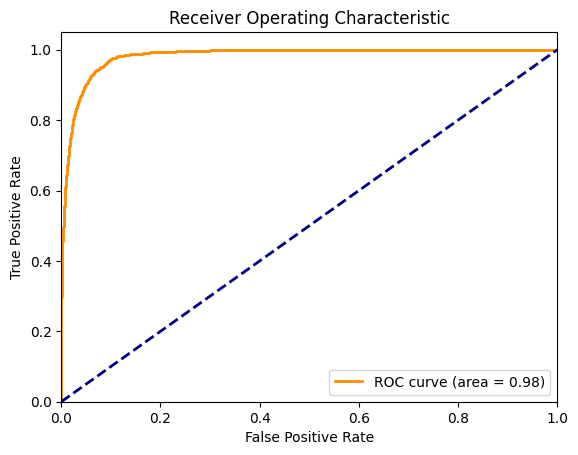

In [187]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % area)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

<h3 style="color:green;" >7.2 Model Evaluation: Rankordering, KS statistics, Gini Coeff</h3>

In [188]:
probabilities = best_model_logistic.predict_proba(X_test_encoded)[:,1]

df_eval = pd.DataFrame({
    'Default Truth': y_test,
    'Default Probability': probabilities
})
df_eval.head(3)

,Default Truth,Default Probability
5939,0,0.039838
26870,0,0.000958
16047,0,0.003527


In [189]:
df_eval['Decile'] = pd.qcut(df_eval['Default Probability'], 10, labels=False, duplicates='drop')
df_eval.head(3)

,Default Truth,Default Probability,Decile
5939,0,0.039838,7
26870,0,0.000958,5
16047,0,0.003527,5


In [190]:
df_decile = df_eval.groupby('Decile').apply(lambda x: pd.Series({
    'Minimum Probability': x['Default Probability'].min(),
    'Maximum Probability': x['Default Probability'].max(),
    'Events': x['Default Truth'].sum(),
    'Non-events': x['Default Truth'].count() - x['Default Truth'].sum(),    
}))
df_decile.reset_index(inplace=True)
df_decile

C:\Users\suman\AppData\Local\Temp\ipykernel_12316\4037021561.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_decile = df_eval.groupby('Decile').apply(lambda x: pd.Series({


,Decile,Minimum Probability,Maximum Probability,Events,Non-events
0,0,1.493324e-09,3.969900e-07,0.0,1250.0
1,1,3.972390e-07,3.238057e-06,0.0,1250.0
2,2,3.245052e-06,1.828816e-05,0.0,1249.0
3,3,1.829719e-05,1.026416e-04,0.0,1250.0
4,4,1.027848e-04,5.507079e-04,0.0,1249.0
5,5,5.508229e-04,3.624253e-03,1.0,1249.0
6,6,3.648816e-03,2.481683e-02,4.0,1245.0
7,7,2.491600e-02,1.856549e-01,13.0,1237.0
8,8,1.856710e-01,8.120893e-01,159.0,1090.0
9,9,8.124374e-01,1.000000e+00,897.0,353.0


In [191]:
df_decile = df_decile.sort_values(by='Decile', ascending=False).reset_index(drop=True)
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events
0,9,8.124374e-01,1.000000e+00,897.0,353.0
1,8,1.856710e-01,8.120893e-01,159.0,1090.0
2,7,2.491600e-02,1.856549e-01,13.0,1237.0
3,6,3.648816e-03,2.481683e-02,4.0,1245.0
4,5,5.508229e-04,3.624253e-03,1.0,1249.0
5,4,1.027848e-04,5.507079e-04,0.0,1249.0
6,3,1.829719e-05,1.026416e-04,0.0,1250.0
7,2,3.245052e-06,1.828816e-05,0.0,1249.0
8,1,3.972390e-07,3.238057e-06,0.0,1250.0
9,0,1.493324e-09,3.969900e-07,0.0,1250.0


In [192]:
df_decile['Event Rate'] = df_decile['Events']*100 / (df_decile['Events']+df_decile['Non-events'])
df_decile['Non-event Rate'] = df_decile['Non-events']*100 / (df_decile['Events']+df_decile['Non-events'])
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate
0,9,8.124374e-01,1.000000e+00,897.0,353.0,71.760000,28.240000
1,8,1.856710e-01,8.120893e-01,159.0,1090.0,12.730184,87.269816
2,7,2.491600e-02,1.856549e-01,13.0,1237.0,1.040000,98.960000
3,6,3.648816e-03,2.481683e-02,4.0,1245.0,0.320256,99.679744
4,5,5.508229e-04,3.624253e-03,1.0,1249.0,0.080000,99.920000
5,4,1.027848e-04,5.507079e-04,0.0,1249.0,0.000000,100.000000
6,3,1.829719e-05,1.026416e-04,0.0,1250.0,0.000000,100.000000
7,2,3.245052e-06,1.828816e-05,0.0,1249.0,0.000000,100.000000
8,1,3.972390e-07,3.238057e-06,0.0,1250.0,0.000000,100.000000
9,0,1.493324e-09,3.969900e-07,0.0,1250.0,0.000000,100.000000


In [193]:
df_decile['Cum Events'] =  df_decile['Events'].cumsum()
df_decile['Cum Non-events'] =  df_decile['Non-events'].cumsum()
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events
0,9,8.124374e-01,1.000000e+00,897.0,353.0,71.760000,28.240000,897.0,353.0
1,8,1.856710e-01,8.120893e-01,159.0,1090.0,12.730184,87.269816,1056.0,1443.0
2,7,2.491600e-02,1.856549e-01,13.0,1237.0,1.040000,98.960000,1069.0,2680.0
3,6,3.648816e-03,2.481683e-02,4.0,1245.0,0.320256,99.679744,1073.0,3925.0
4,5,5.508229e-04,3.624253e-03,1.0,1249.0,0.080000,99.920000,1074.0,5174.0
5,4,1.027848e-04,5.507079e-04,0.0,1249.0,0.000000,100.000000,1074.0,6423.0
6,3,1.829719e-05,1.026416e-04,0.0,1250.0,0.000000,100.000000,1074.0,7673.0
7,2,3.245052e-06,1.828816e-05,0.0,1249.0,0.000000,100.000000,1074.0,8922.0
8,1,3.972390e-07,3.238057e-06,0.0,1250.0,0.000000,100.000000,1074.0,10172.0
9,0,1.493324e-09,3.969900e-07,0.0,1250.0,0.000000,100.000000,1074.0,11422.0


In [194]:
df_decile['Cum Event Rate'] = df_decile['Cum Events'] * 100 / df_decile['Events'].sum()
df_decile['Cum Non-event Rate'] = df_decile['Cum Non-events']*100 / df_decile['Non-events'].sum()
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events,Cum Event Rate,Cum Non-event Rate
0,9,8.124374e-01,1.000000e+00,897.0,353.0,71.760000,28.240000,897.0,353.0,83.519553,3.090527
1,8,1.856710e-01,8.120893e-01,159.0,1090.0,12.730184,87.269816,1056.0,1443.0,98.324022,12.633514
2,7,2.491600e-02,1.856549e-01,13.0,1237.0,1.040000,98.960000,1069.0,2680.0,99.534451,23.463492
3,6,3.648816e-03,2.481683e-02,4.0,1245.0,0.320256,99.679744,1073.0,3925.0,99.906890,34.363509
4,5,5.508229e-04,3.624253e-03,1.0,1249.0,0.080000,99.920000,1074.0,5174.0,100.000000,45.298547
5,4,1.027848e-04,5.507079e-04,0.0,1249.0,0.000000,100.000000,1074.0,6423.0,100.000000,56.233584
6,3,1.829719e-05,1.026416e-04,0.0,1250.0,0.000000,100.000000,1074.0,7673.0,100.000000,67.177377
7,2,3.245052e-06,1.828816e-05,0.0,1249.0,0.000000,100.000000,1074.0,8922.0,100.000000,78.112415
8,1,3.972390e-07,3.238057e-06,0.0,1250.0,0.000000,100.000000,1074.0,10172.0,100.000000,89.056207
9,0,1.493324e-09,3.969900e-07,0.0,1250.0,0.000000,100.000000,1074.0,11422.0,100.000000,100.000000


In [195]:
df_decile['KS'] = abs(df_decile['Cum Event Rate'] - df_decile['Cum Non-event Rate'])
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events,Cum Event Rate,Cum Non-event Rate,KS
0,9,8.124374e-01,1.000000e+00,897.0,353.0,71.760000,28.240000,897.0,353.0,83.519553,3.090527,80.429026
1,8,1.856710e-01,8.120893e-01,159.0,1090.0,12.730184,87.269816,1056.0,1443.0,98.324022,12.633514,85.690508
2,7,2.491600e-02,1.856549e-01,13.0,1237.0,1.040000,98.960000,1069.0,2680.0,99.534451,23.463492,76.070959
3,6,3.648816e-03,2.481683e-02,4.0,1245.0,0.320256,99.679744,1073.0,3925.0,99.906890,34.363509,65.543381
4,5,5.508229e-04,3.624253e-03,1.0,1249.0,0.080000,99.920000,1074.0,5174.0,100.000000,45.298547,54.701453
5,4,1.027848e-04,5.507079e-04,0.0,1249.0,0.000000,100.000000,1074.0,6423.0,100.000000,56.233584,43.766416
6,3,1.829719e-05,1.026416e-04,0.0,1250.0,0.000000,100.000000,1074.0,7673.0,100.000000,67.177377,32.822623
7,2,3.245052e-06,1.828816e-05,0.0,1249.0,0.000000,100.000000,1074.0,8922.0,100.000000,78.112415,21.887585
8,1,3.972390e-07,3.238057e-06,0.0,1250.0,0.000000,100.000000,1074.0,10172.0,100.000000,89.056207,10.943793
9,0,1.493324e-09,3.969900e-07,0.0,1250.0,0.000000,100.000000,1074.0,11422.0,100.000000,100.000000,0.000000


To assess whether rank ordering is followed, we should look at whether higher deciles (those with higher predicted probabilities) have higher event rates compared to lower deciles. Rank ordering means that as you move from the top decile to the bottom decile, the event rate should generally decrease.

Non-Events - termed as good (customers) who do not default. Events - termed as bad (customers) who default.

Events and Non-Events terms are interchanged based on usecase to usecase.

eg: for marketing usecase, which customer to reach out (who will take loan based on offers) will be events - here it will termed as good, and the customers who will not take loans will be non-events (bad).

**Insights from the Decile Table**

1. Top Deciles

* The first decile (Decile 9) has a high event rate of 72.00% and a non-event rate of 28.00%. This indicates that the model is highly confident in predicting events in this decile.
* The second decile (Decile 8) also shows a significant event rate of 12.72%, with a cumulative event rate reaching 98.6%.

2. Middle Deciles:

* Deciles 7 and 6 show a significant drop in event rates

3. Lower Deciles:

* Deciles 5 to 0 show zero events, with all predictions being non-events. These deciles collectively have a non-event rate of 100%.

4. KS Statistic:

* The KS statistic, which is the maximum difference between cumulative event rates and cumulative non-event rates, is highest at Decile 8 with a value of 85.98%. This suggests that the model performs best at distinguishing between events and non-events up to this decile.

* The KS value gradually decreases in the following deciles, indicating a decrease in model performance for distinguishing between events and non-events.

**KS Value**

The highest KS value is 85.98%, found at Decile 8. This indicates that the model's performance in distinguishing between events and non-events is most significant at this decile. (If KS is in top 3 decile and score above 40, it is considered a good predictive model.)

In [196]:
gini_coefficient = 2 * area - 1

print("AUC:", area)
print("Gini Coefficient:", gini_coefficient)

AUC: 0.9828461654091698
Gini Coefficient: 0.9656923308183396


AUC of 0.98: The model is very good at distinguishing between events and non-events.

Gini coefficient of 0.96: This further confirms that the model is highly effective in its predictions, with almost perfect rank ordering capability.

The Gini coefficient ranges from -1 to 1, where a value closer to 1 signifies a perfect model, 0 indicates a model with no discriminative power, and -1 signifies a perfectly incorrect model.

<h2 align="center" style="color:blue;">8. Finalize The Model and Visualize Feature Importance</h2>

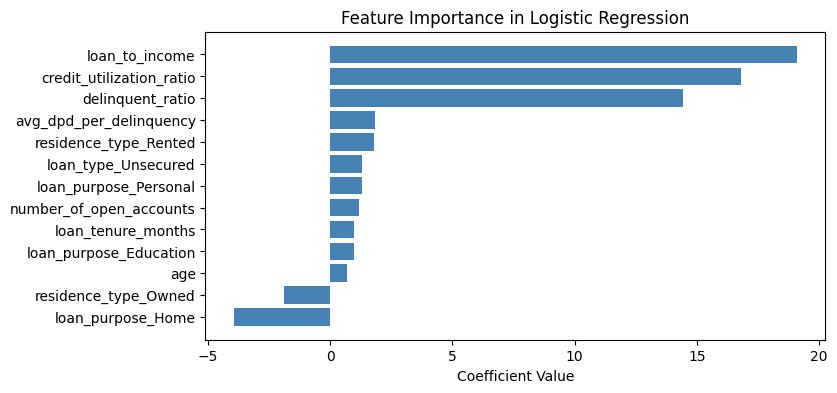

In [197]:
final_model = best_model_logistic

feature_importance = final_model.coef_[0]

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train_encoded.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Logistic Regression')
plt.show()

<h2 align="center" style="color:blue;">9. Save The Model</h2>

In [198]:
X_test_encoded.head(2)

,credit_utilization_ratio,delinquent_ratio,loan_to_income,avg_dpd_per_delinquency,loan_tenure_months,number_of_open_accounts,age,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,residence_type_Owned,residence_type_Rented,loan_type_Unsecured
5939,0.878788,0.17,0.076923,0.47,0.188679,0.666667,0.846154,False,False,False,True,False,False
26870,0.454545,0.00,0.337995,0.00,0.886792,1.000000,0.346154,True,False,False,True,False,False


In [199]:
X_test_encoded.columns

Index(['credit_utilization_ratio', 'delinquent_ratio', 'loan_to_income',
       'avg_dpd_per_delinquency', 'loan_tenure_months',
       'number_of_open_accounts', 'age', 'loan_purpose_Education',
       'loan_purpose_Home', 'loan_purpose_Personal', 'residence_type_Owned',
       'residence_type_Rented', 'loan_type_Unsecured'],
      dtype='object')

In [200]:
cols_to_scale

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'sanction_amount', 'processing_fee', 'gst',
       'net_disbursement', 'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'loan_to_income', 'delinquent_ratio',
       'avg_dpd_per_delinquency'],
      dtype='object')

In [201]:
X_train_encoded.columns

Index(['credit_utilization_ratio', 'delinquent_ratio', 'loan_to_income',
       'avg_dpd_per_delinquency', 'loan_tenure_months',
       'number_of_open_accounts', 'age', 'loan_purpose_Education',
       'loan_purpose_Home', 'loan_purpose_Personal', 'residence_type_Owned',
       'residence_type_Rented', 'loan_type_Unsecured'],
      dtype='object')

In [202]:
from joblib import dump

model_data = {
            'model': final_model,
            'features':  X_train_encoded.columns,
            'scaler': scaler,
            'cols_to_scale': cols_to_scale
        
        }
dump(model_data, '../artifacts/model_data.joblib')

['../artifacts/model_data.joblib']

In [203]:
final_model.coef_, final_model.intercept_

(array([[16.80239356, 14.41549385, 19.11105486,  1.84615696,  0.97204748,
          1.16657261,  0.68130276,  0.96300057, -3.956313  ,  1.30736227,
         -1.87788472,  1.80076338,  1.30736227]]),
 array([-22.39613995]))

In [204]:
print(cols_to_scale)
print(scaler.feature_names_in_)

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'sanction_amount', 'processing_fee', 'gst',
       'net_disbursement', 'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'loan_to_income', 'delinquent_ratio',
       'avg_dpd_per_delinquency'],
      dtype='object')
['age' 'number_of_dependants' 'years_at_current_address' 'zipcode'
 'number_of_open_accounts' 'number_of_closed_accounts' 'enquiry_count'
 'credit_utilization_ratio' 'sanction_amount' 'processing_fee' 'gst'
 'net_disbursement' 'loan_tenure_months' 'principal_outstanding'
 'bank_balance_at_application' 'loan_to_income' 'delinquent_ratio'
 'avg_dpd_per_delinquency']
